In [1]:
print("Hello Deepi")

Hello Deepi


In [2]:
import pandas as pd

data = {
    "Gene1": [2.3, 4.5, 1.2],
    "Gene2": [5.1, 2.2, 3.3]
}

df = pd.DataFrame(data)

print(df)

   Gene1  Gene2
0    2.3    5.1
1    4.5    2.2
2    1.2    3.3


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

print(cancer.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [5]:
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

df['target'] = cancer.target

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [6]:
print(df.shape)

(569, 31)


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [9]:
y_pred = model.predict(X_test)

print(y_pred)

[1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[40  3]
 [ 1 70]]


In [12]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                 Feature  Importance
7    mean concave points    0.177420
27  worst concave points    0.150098
20          worst radius    0.121906
22       worst perimeter    0.109148
23            worst area    0.102502
6         mean concavity    0.044553
13            area error    0.043704
3              mean area    0.030351
26       worst concavity    0.022792
21         worst texture    0.021588


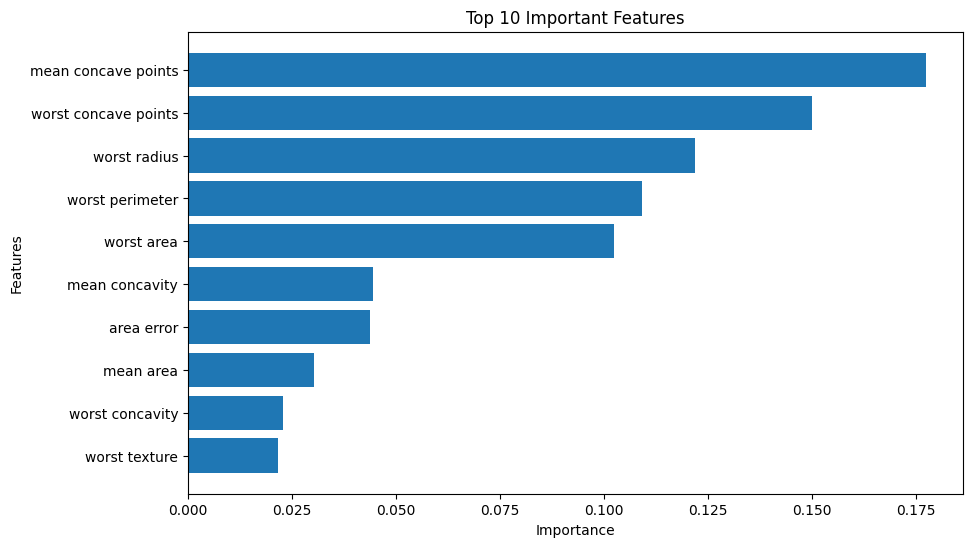

In [13]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

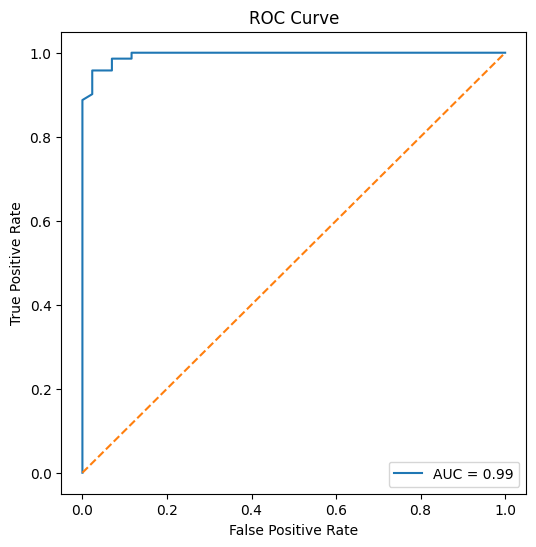

In [14]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend(loc='lower right')

plt.show()

In [15]:
import pandas as pd

df = pd.read_csv('GSE45827_series_matrix.txt.gz',
                 sep='\t',
                 comment='!',
                 compression='gzip')

print(df.head())

      ID_REF  GSM1116084  GSM1116085  GSM1116086  GSM1116087  GSM1116088  \
0  1007_s_at     9.47065     9.67440    10.20800    10.11420    11.16360   
1    1053_at     8.36311     8.72194     7.78601     9.44537     7.71242   
2     117_at     5.95426     7.02523     6.39671     4.56023     5.29008   
3    1294_at     6.02119     7.24581     6.85310     5.42786     7.51120   
4    1316_at     3.22997     3.29352     3.26204     3.34766     3.59086   

   GSM1116089  GSM1116090  GSM1116091  GSM1116092  ...  GSM1116229  \
0    10.00690     9.53932     9.00187     6.54074  ...     9.96811   
1     7.84274     7.56238     8.01540     9.37874  ...     7.25745   
2     6.21590     6.42180     6.23554     5.43541  ...     8.35832   
3     5.79719     7.36700     7.17268     7.72472  ...     7.18591   
4     3.40108     3.27663     3.14212     3.28420  ...     3.50312   

   GSM1116230  GSM1116231  GSM1116232  GSM1116233  GSM1116234  GSM1116235  \
0    10.10680    10.03290     9.84599    10.7

In [16]:
print(df.shape)

(29873, 156)


In [17]:
print(df.columns)

Index(['ID_REF', 'GSM1116084', 'GSM1116085', 'GSM1116086', 'GSM1116087',
       'GSM1116088', 'GSM1116089', 'GSM1116090', 'GSM1116091', 'GSM1116092',
       ...
       'GSM1116229', 'GSM1116230', 'GSM1116231', 'GSM1116232', 'GSM1116233',
       'GSM1116234', 'GSM1116235', 'GSM1116236', 'GSM1116237', 'GSM1116238'],
      dtype='object', length=156)


In [18]:
print(df.isnull().sum())

ID_REF        0
GSM1116084    0
GSM1116085    0
GSM1116086    0
GSM1116087    0
             ..
GSM1116234    0
GSM1116235    0
GSM1116236    0
GSM1116237    0
GSM1116238    0
Length: 156, dtype: int64


In [19]:
df = df.dropna()

print(df.shape)

(29873, 156)


In [20]:
print(df.head())

      ID_REF  GSM1116084  GSM1116085  GSM1116086  GSM1116087  GSM1116088  \
0  1007_s_at     9.47065     9.67440    10.20800    10.11420    11.16360   
1    1053_at     8.36311     8.72194     7.78601     9.44537     7.71242   
2     117_at     5.95426     7.02523     6.39671     4.56023     5.29008   
3    1294_at     6.02119     7.24581     6.85310     5.42786     7.51120   
4    1316_at     3.22997     3.29352     3.26204     3.34766     3.59086   

   GSM1116089  GSM1116090  GSM1116091  GSM1116092  ...  GSM1116229  \
0    10.00690     9.53932     9.00187     6.54074  ...     9.96811   
1     7.84274     7.56238     8.01540     9.37874  ...     7.25745   
2     6.21590     6.42180     6.23554     5.43541  ...     8.35832   
3     5.79719     7.36700     7.17268     7.72472  ...     7.18591   
4     3.40108     3.27663     3.14212     3.28420  ...     3.50312   

   GSM1116230  GSM1116231  GSM1116232  GSM1116233  GSM1116234  GSM1116235  \
0    10.10680    10.03290     9.84599    10.7

In [21]:
print(df.shape)

(29873, 156)


In [22]:
print(df.isnull().sum().sum())

0


In [23]:
df_transposed = df.set_index('ID_REF').T

print(df_transposed.head())

ID_REF      1007_s_at  1053_at   117_at  1294_at  1316_at  1405_i_at  1438_at  \
GSM1116084    9.47065  8.36311  5.95426  6.02119  3.22997   10.82220  4.39698   
GSM1116085    9.67440  8.72194  7.02523  7.24581  3.29352    9.29455  6.68936   
GSM1116086   10.20800  7.78601  6.39671  6.85310  3.26204    9.45727  5.46440   
GSM1116087   10.11420  9.44537  4.56023  5.42786  3.34766   11.51270  5.29748   
GSM1116088   11.16360  7.71242  5.29008  7.51120  3.59086    8.83075  6.81821   

ID_REF      1487_at  1552256_a_at  1552257_a_at  ...  87100_at  89476_r_at  \
GSM1116084  6.65320      10.91320      10.07510  ...   3.90703     7.67662   
GSM1116085  7.20820       9.32204       9.34476  ...   5.84253     7.32080   
GSM1116086  6.68974       7.73131       8.43573  ...   4.32990     7.53787   
GSM1116087  6.87276      10.39210       9.63893  ...   5.72709     7.86515   
GSM1116088  6.45744       7.05836       9.37463  ...   4.66965     7.33174   

ID_REF      90265_at  90610_at  91617_at  91

In [24]:
labels = [1]*65 + [0]*66

print(len(labels))

131


In [25]:
df_transposed['target'] = labels

print(df_transposed.head())

ValueError: Length of values (131) does not match length of index (155)

In [26]:
print(df_transposed.shape)

(155, 29873)


In [27]:
labels = [1]*78 + [0]*77

print(len(labels))

155


In [28]:
df_transposed['target'] = labels

print(df_transposed.head())

ID_REF      1007_s_at  1053_at   117_at  1294_at  1316_at  1405_i_at  1438_at  \
GSM1116084    9.47065  8.36311  5.95426  6.02119  3.22997   10.82220  4.39698   
GSM1116085    9.67440  8.72194  7.02523  7.24581  3.29352    9.29455  6.68936   
GSM1116086   10.20800  7.78601  6.39671  6.85310  3.26204    9.45727  5.46440   
GSM1116087   10.11420  9.44537  4.56023  5.42786  3.34766   11.51270  5.29748   
GSM1116088   11.16360  7.71242  5.29008  7.51120  3.59086    8.83075  6.81821   

ID_REF      1487_at  1552256_a_at  1552257_a_at  ...  89476_r_at  90265_at  \
GSM1116084  6.65320      10.91320      10.07510  ...     7.67662   8.58529   
GSM1116085  7.20820       9.32204       9.34476  ...     7.32080   6.21915   
GSM1116086  6.68974       7.73131       8.43573  ...     7.53787   7.86806   
GSM1116087  6.87276      10.39210       9.63893  ...     7.86515   8.79839   
GSM1116088  6.45744       7.05836       9.37463  ...     7.33174   7.01692   

ID_REF      90610_at  91617_at  91684_g_at  

In [29]:
from sklearn.model_selection import train_test_split

X = df_transposed.drop('target', axis=1)
y = df_transposed['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(124, 29873)
(31, 29873)


In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [31]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9032258064516129


In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[13  3]
 [ 0 15]]


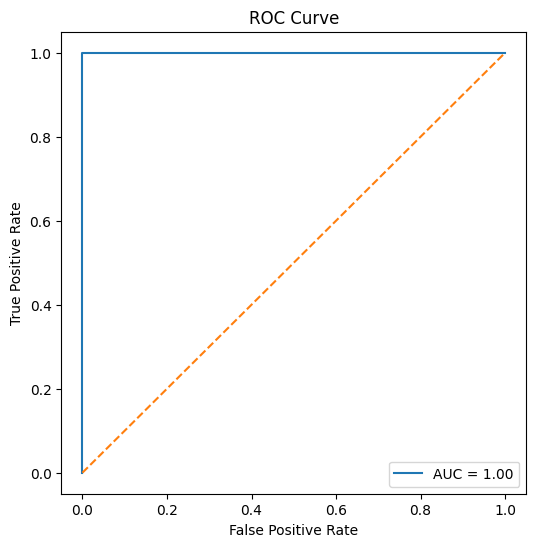

In [34]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend(loc='lower right')

plt.show()

In [35]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Gene': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

               Gene  Importance
720    1555483_x_at    0.013387
7273      205862_at    0.012043
28387     242251_at    0.011633
6340    204650_s_at    0.011318
24913     232944_at    0.010922
1362   1558448_a_at    0.010405
2839      200934_at    0.010296
21525     227198_at    0.009426
13448     215593_at    0.009264
20461     226030_at    0.008326


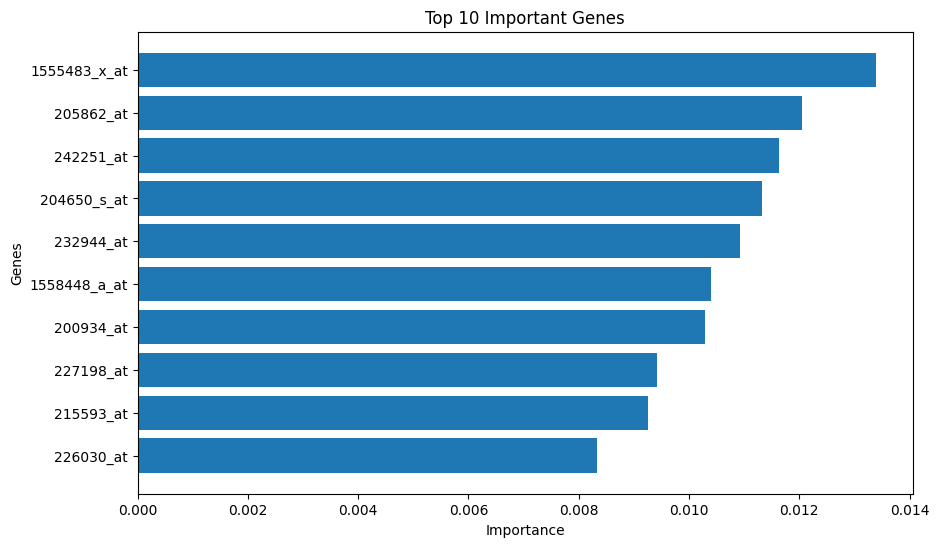

In [36]:
top_genes = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_genes['Gene'], top_genes['Importance'])

plt.xlabel("Importance")
plt.ylabel("Genes")
plt.title("Top 10 Important Genes")

plt.gca().invert_yaxis()

plt.show()

In [37]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9032258064516129


In [38]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=5000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 1.0


In [39]:
models = ['Random Forest', 'SVM', 'Logistic Regression']

accuracies = [
    accuracy,
    svm_accuracy,
    lr_accuracy
]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

print(comparison_df)

                 Model  Accuracy
0        Random Forest  0.903226
1                  SVM  0.903226
2  Logistic Regression  1.000000


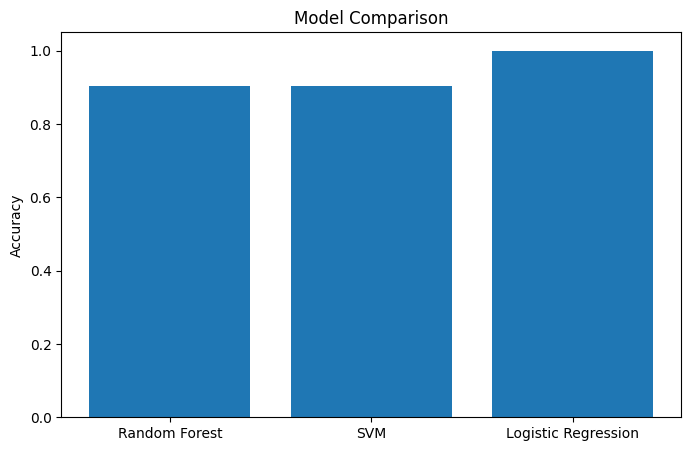

In [40]:
plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()

In [41]:
from sklearn.decomposition import PCA

In [42]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

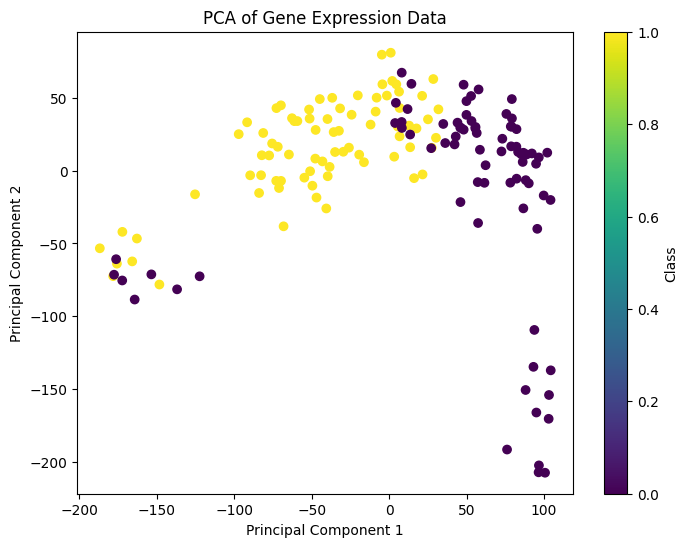

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA of Gene Expression Data")

plt.colorbar(label='Class')

plt.show()

In [44]:
top20_genes = feature_importance.head(20)['Gene']

heatmap_data = X[top20_genes]

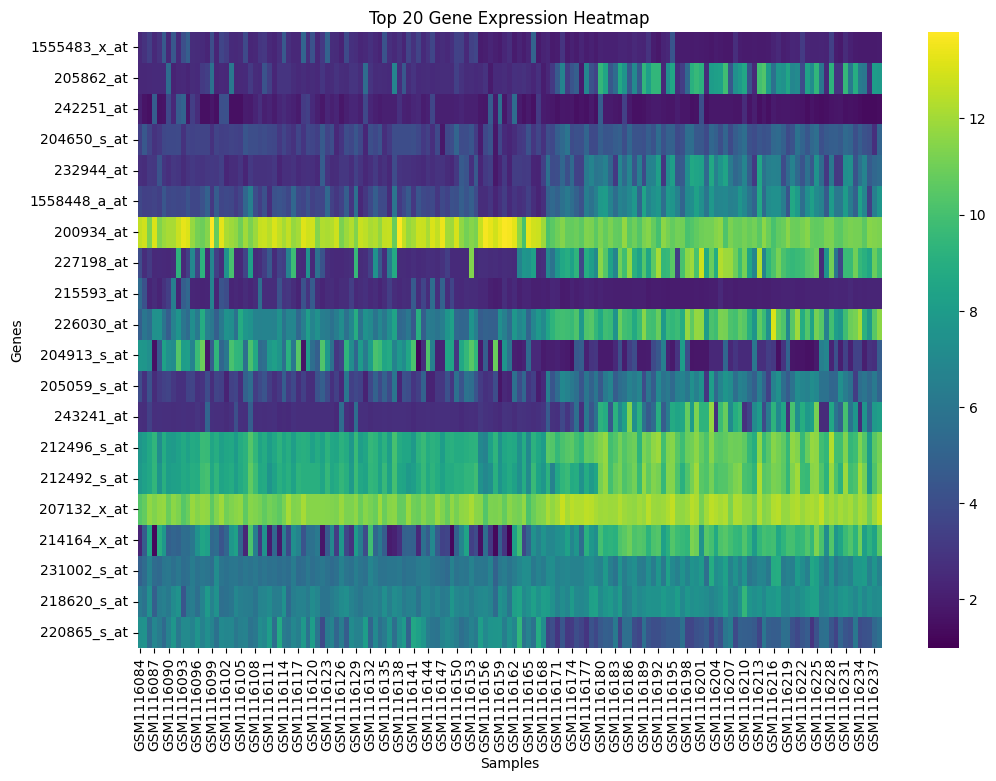

In [45]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data.T,
    cmap='viridis'
)

plt.title("Top 20 Gene Expression Heatmap")

plt.xlabel("Samples")
plt.ylabel("Genes")

plt.show()

In [46]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:", cv_scores)

print("Average CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.77419355 1.         1.         1.         0.77419355]
Average CV Accuracy: 0.9096774193548388


In [47]:
from scipy.stats import ttest_ind

cancer_samples = df_transposed[df_transposed['target']==1]
normal_samples = df_transposed[df_transposed['target']==0]

gene = feature_importance.iloc[0]['Gene']

t_stat, p_value = ttest_ind(
    cancer_samples[gene],
    normal_samples[gene]
)

print("Gene:", gene)
print("P-value:", p_value)

Gene: 1555483_x_at
P-value: 7.764694610336333e-11


In [49]:
if p_value < 0.05:
    print("Statistically Significant")
else:
    print("Not Significant")

Statistically Significant


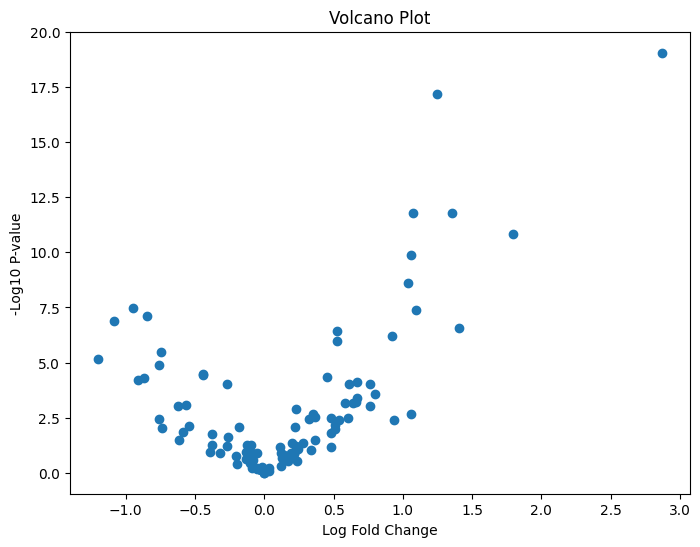

In [50]:
log_fc = []
p_values = []

genes = X.columns[:100]

for gene in genes:

    cancer_mean = cancer_samples[gene].mean()
    normal_mean = normal_samples[gene].mean()

    fc = cancer_mean - normal_mean

    t_stat, p = ttest_ind(
        cancer_samples[gene],
        normal_samples[gene]
    )

    log_fc.append(fc)
    p_values.append(-np.log10(p))

plt.figure(figsize=(8,6))

plt.scatter(log_fc, p_values)

plt.xlabel("Log Fold Change")
plt.ylabel("-Log10 P-value")

plt.title("Volcano Plot")

plt.show()

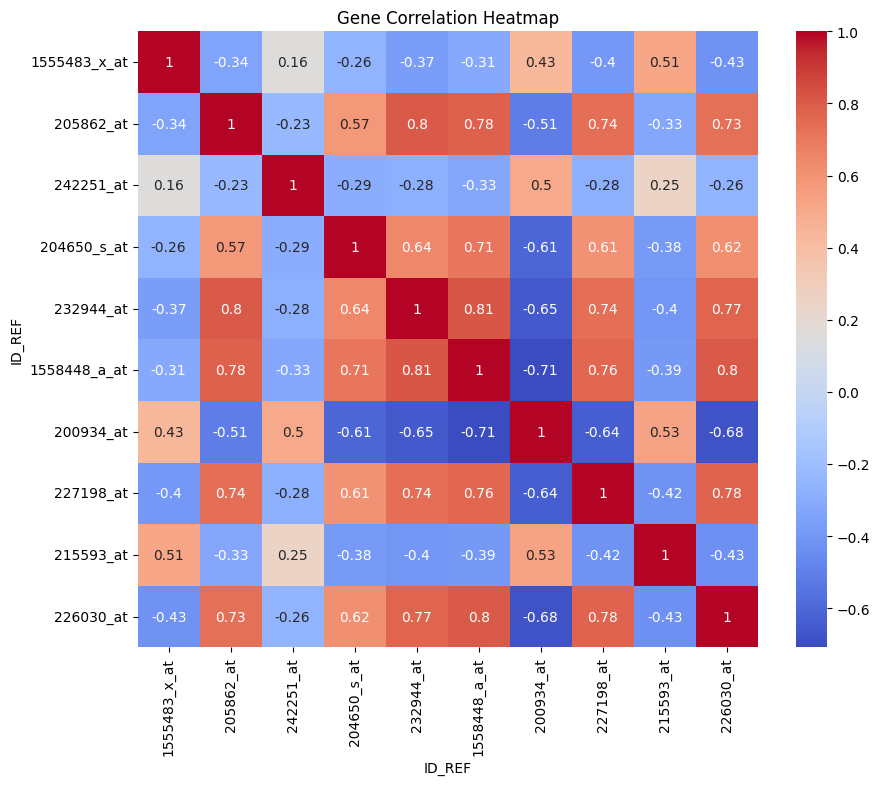

In [51]:
top10 = feature_importance.head(10)['Gene']

corr = X[top10].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Gene Correlation Heatmap")

plt.show()

In [52]:
print(feature_importance.head(10))

               Gene  Importance
720    1555483_x_at    0.013387
7273      205862_at    0.012043
28387     242251_at    0.011633
6340    204650_s_at    0.011318
24913     232944_at    0.010922
1362   1558448_a_at    0.010405
2839      200934_at    0.010296
21525     227198_at    0.009426
13448     215593_at    0.009264
20461     226030_at    0.008326


In [53]:
print(X.columns[:10])

Index(['1007_s_at', '1053_at', '117_at', '1294_at', '1316_at', '1405_i_at',
       '1438_at', '1487_at', '1552256_a_at', '1552257_a_at'],
      dtype='object', name='ID_REF')


In [54]:
print(df.head())

      ID_REF  GSM1116084  GSM1116085  GSM1116086  GSM1116087  GSM1116088  \
0  1007_s_at     9.47065     9.67440    10.20800    10.11420    11.16360   
1    1053_at     8.36311     8.72194     7.78601     9.44537     7.71242   
2     117_at     5.95426     7.02523     6.39671     4.56023     5.29008   
3    1294_at     6.02119     7.24581     6.85310     5.42786     7.51120   
4    1316_at     3.22997     3.29352     3.26204     3.34766     3.59086   

   GSM1116089  GSM1116090  GSM1116091  GSM1116092  ...  GSM1116229  \
0    10.00690     9.53932     9.00187     6.54074  ...     9.96811   
1     7.84274     7.56238     8.01540     9.37874  ...     7.25745   
2     6.21590     6.42180     6.23554     5.43541  ...     8.35832   
3     5.79719     7.36700     7.17268     7.72472  ...     7.18591   
4     3.40108     3.27663     3.14212     3.28420  ...     3.50312   

   GSM1116230  GSM1116231  GSM1116232  GSM1116233  GSM1116234  GSM1116235  \
0    10.10680    10.03290     9.84599    10.7

In [55]:
print(df.columns[:5])

Index(['ID_REF', 'GSM1116084', 'GSM1116085', 'GSM1116086', 'GSM1116087'], dtype='object')


In [56]:
print(df.index[:5])

RangeIndex(start=0, stop=5, step=1)


In [57]:
print(df.iloc[:5, :5])

      ID_REF  GSM1116084  GSM1116085  GSM1116086  GSM1116087
0  1007_s_at     9.47065     9.67440    10.20800    10.11420
1    1053_at     8.36311     8.72194     7.78601     9.44537
2     117_at     5.95426     7.02523     6.39671     4.56023
3    1294_at     6.02119     7.24581     6.85310     5.42786
4    1316_at     3.22997     3.29352     3.26204     3.34766


In [58]:
print(df.columns)

Index(['ID_REF', 'GSM1116084', 'GSM1116085', 'GSM1116086', 'GSM1116087',
       'GSM1116088', 'GSM1116089', 'GSM1116090', 'GSM1116091', 'GSM1116092',
       ...
       'GSM1116229', 'GSM1116230', 'GSM1116231', 'GSM1116232', 'GSM1116233',
       'GSM1116234', 'GSM1116235', 'GSM1116236', 'GSM1116237', 'GSM1116238'],
      dtype='object', length=156)


In [59]:
print(df['ID_REF'].head(10))

0       1007_s_at
1         1053_at
2          117_at
3         1294_at
4         1316_at
5       1405_i_at
6         1438_at
7         1487_at
8    1552256_a_at
9    1552257_a_at
Name: ID_REF, dtype: object


In [61]:
import os

print(os.listdir())

['.config', 'GPL570.annot.gz', 'sample_data', 'GSE45827_series_matrix.txt.gz']


In [63]:
with open('GPL570.annot.gz', 'rb') as f:
    print(f.read(200))

b"\x1f\x8b\x08\x08\x18\r\xaaW\x00\x03GPL570.annot\x00\xbc\\[\x8f\xdc\xb6\x92~\x96\x7f\x85\x0e\xf2pl\xc0=\x16u\xd7\x02\xfb0\x19;\xb6O\x12{\xe0L\x80,\x16\xbb\x03\xb5\x9a\xdd\xcd\xb5$\xb6%\xf5d\xda\xbf\xfeTQ\x17\x16u\xe9i'\xc6\x1aH\xdc\x14\x8b\xb7bU\xb1\xeac\xd1\xff{]\x96\xb2I\x1b!\xcbg\xff\xd0\xbf\xef7i\xc3\xed\xff\xb4\xaf\x8f;\xdbIl\xd7a\xa1Q}\xc8\xd3f+\xab\x02H\xde\xde\xfe\x12D\xcel\xed}#\x9a\x1c\xbb\xf9\xefwoW\xbf3\xcf\xbb\xbf\xcd\x8f\xf5\xbd\xfb?\xf6\xf5v{*xS\x89G\xfb\xdd\xb1HK\xfb-/e\xc1m$\xb2\x91\xc8v\xaf\x1c\xfb\xba\xaa\xd2\xd3|\xcf\xb2\xda\xa5\xa5\xa8q"


In [67]:
import gzip

with gzip.open('GPL570.annot.gz', 'rt') as f:
    for i in range(20):
        print(f.readline())

^Annotation

!Annotation_date = Aug 09 2016

!Annotation_platform = GPL570

!Annotation_platform_title = [HG-U133_Plus_2] Affymetrix Human Genome U133 Plus 2.0 Array

!Annotation_platform_organism = Homo sapiens

#ID = ID from Platform data table

#Gene title = Entrez Gene name

#Gene symbol = Entrez Gene symbol

#Gene ID = Entrez Gene identifier

#UniGene title = Entrez UniGene name

#UniGene symbol = Entrez UniGene symbol

#UniGene ID = Entrez UniGene identifier

#Nucleotide Title = Entrez Nucleotide title

#GI = GenBank identifier

#GenBank Accession = GenBank accession

#Platform_CLONEID = CLONE_ID from Platform data table

#Platform_ORF = ORF from Platform data table

#Platform_SPOTID = SPOT_ID from Platform data table

#Chromosome location = Entrez gene chromosome and location

#Chromosome annotation = Entrez gene chromosome annotation



In [72]:
import gzip

with gzip.open('GPL570.annot.gz', 'rt', errors='ignore') as f:
    for line in f:
        if line.startswith('#ID'):
            print(line)
            break

#ID = ID from Platform data table



In [74]:
import pandas as pd

url = "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPLnnn/GPL570/annot/GPL570.annot.gz"

annot = pd.read_csv(
    url,
    sep='\t',
    compression='gzip',
    skiprows=27,
    low_memory=False
)

print(annot.head())
print(annot.columns)

          ID                                         Gene title  \
0  1007_s_at  microRNA 4640///discoidin domain receptor tyro...   
1    1053_at                     replication factor C subunit 2   
2     117_at       heat shock protein family A (Hsp70) member 6   
3     121_at                                       paired box 8   
4  1255_g_at                     guanylate cyclase activator 1A   

      Gene symbol          Gene ID UniGene title UniGene symbol UniGene ID  \
0  MIR4640///DDR1  100616237///780           NaN            NaN        NaN   
1            RFC2             5982           NaN            NaN        NaN   
2           HSPA6             3310           NaN            NaN        NaN   
3            PAX8             7849           NaN            NaN        NaN   
4          GUCA1A             2978           NaN            NaN        NaN   

                                    Nucleotide Title         GI  \
0  Human receptor tyrosine kinase DDR gene, compl...  1753221

In [75]:
annot = annot[['ID', 'Gene symbol']]
annot.head()

,ID,Gene symbol
0,1007_s_at,MIR4640///DDR1
1,1053_at,RFC2
2,117_at,HSPA6
3,121_at,PAX8
4,1255_g_at,GUCA1A


In [76]:
# expression dataset oda first column name check
print(df.columns[:5])

Index(['ID_REF', 'GSM1116084', 'GSM1116085', 'GSM1116086', 'GSM1116087'], dtype='object')


In [77]:
merged = pd.merge(
    df,
    annot,
    left_on='ID_REF',
    right_on='ID',
    how='inner'
)

print(merged.head())

      ID_REF  GSM1116084  GSM1116085  GSM1116086  GSM1116087  GSM1116088  \
0  1007_s_at     9.47065     9.67440    10.20800    10.11420    11.16360   
1    1053_at     8.36311     8.72194     7.78601     9.44537     7.71242   
2     117_at     5.95426     7.02523     6.39671     4.56023     5.29008   
3    1294_at     6.02119     7.24581     6.85310     5.42786     7.51120   
4    1316_at     3.22997     3.29352     3.26204     3.34766     3.59086   

   GSM1116089  GSM1116090  GSM1116091  GSM1116092  ...  GSM1116231  \
0    10.00690     9.53932     9.00187     6.54074  ...    10.03290   
1     7.84274     7.56238     8.01540     9.37874  ...     7.41607   
2     6.21590     6.42180     6.23554     5.43541  ...     4.50611   
3     5.79719     7.36700     7.17268     7.72472  ...     7.44448   
4     3.40108     3.27663     3.14212     3.28420  ...     3.31572   

   GSM1116232  GSM1116233  GSM1116234  GSM1116235  GSM1116236  GSM1116237  \
0     9.84599    10.75850    10.55470     9.4

In [78]:
samples = df.columns[1:]

print("Total samples:", len(samples))
print(samples[:10])

Total samples: 155
Index(['GSM1116084', 'GSM1116085', 'GSM1116086', 'GSM1116087', 'GSM1116088',
       'GSM1116089', 'GSM1116090', 'GSM1116091', 'GSM1116092', 'GSM1116093'],
      dtype='object')


In [79]:
print(df.shape)

(29873, 156)


In [80]:
import os

print(os.listdir())

['.config', 'GPL570.annot.gz', 'sample_data', 'GSE45827_series_matrix.txt.gz']


In [81]:
labels = [0]*11 + [1]*144

print("Normal:", labels.count(0))
print("Cancer:", labels.count(1))

Normal: 11
Cancer: 144


In [82]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, 1:].T
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(124, 29873)
(31, 29873)


In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

acc = accuracy_score(y_test, pred)

print("Accuracy:", acc)

Accuracy: 0.967741935483871


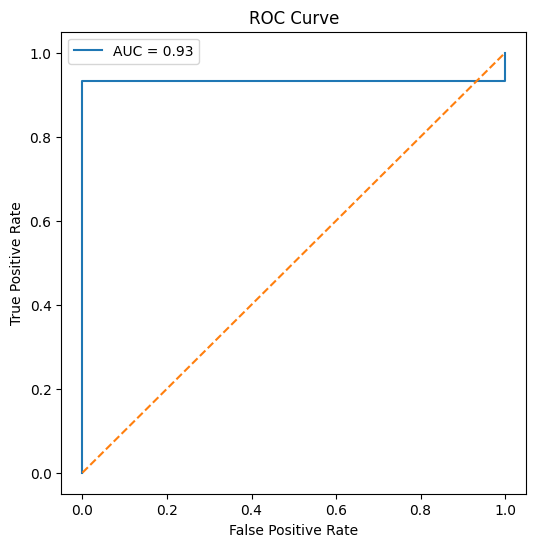

In [84]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.show()

In [85]:
import pandas as pd

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Gene': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(20))

        Gene  Importance
8998    8998    0.012047
17608  17608    0.011388
12938  12938    0.010091
9890    9890    0.010000
27884  27884    0.009981
26952  26952    0.009011
27093  27093    0.008675
24899  24899    0.008595
323      323    0.008282
9748    9748    0.008263
9416    9416    0.008240
16601  16601    0.008187
119      119    0.007933
26111  26111    0.007621
6553    6553    0.007506
566      566    0.007373
5419    5419    0.006794
27032  27032    0.006571
9853    9853    0.006497
26945  26945    0.006497


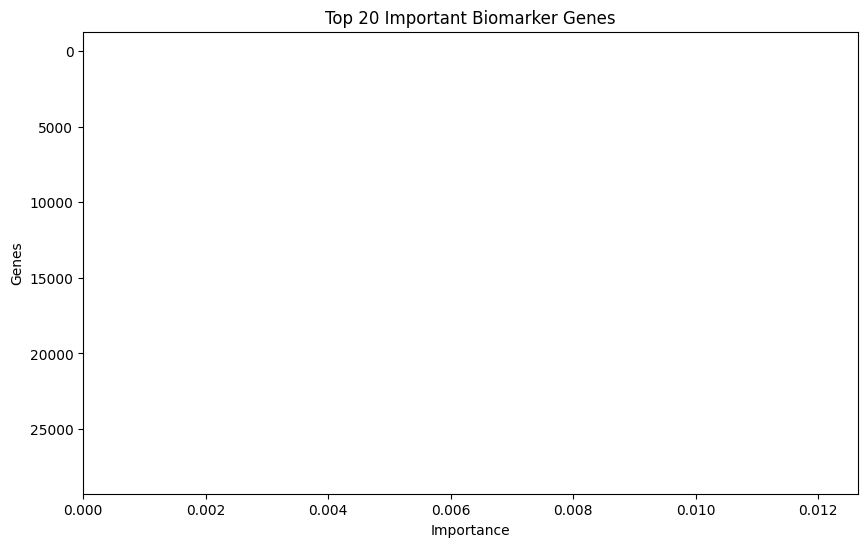

In [86]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20['Gene'], top20['Importance'])

plt.xlabel('Importance')
plt.ylabel('Genes')

plt.title('Top 20 Important Biomarker Genes')

plt.gca().invert_yaxis()

plt.show()

In [88]:
X = merged.iloc[:, 1:156].T

X.columns = merged['Gene symbol'].astype(str)

print(X.columns[:10])

Index(['MIR4640///DDR1', 'RFC2', 'HSPA6', 'MIR5193///UBA7', 'THRA', 'CCL5',
       'EPHB3', 'ESRRA', 'SCARB1', 'TTLL12'],
      dtype='object', name='Gene symbol')


In [89]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.967741935483871


In [90]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Gene': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(20))

           Gene  Importance
27068       nan    0.014467
712      MCOLN2    0.014368
1826   ANKRD30B    0.011427
242     CYP4Z2P    0.010644
20474      TDP1    0.010110
27793    FRG1JP    0.009788
16977    KCNMA1    0.009429
737      GUSBP2    0.009333
9593       FUT4    0.008653
692      DUSP16    0.008293
26552       nan    0.008263
13095      AFDN    0.008181
6652     STAT5B    0.007964
16438    SPATA6    0.007747
22412   CAMK2N1    0.007715
26321   GUCY1A2    0.007373
10311     KITLG    0.007142
28913       nan    0.007100
16441       MAK    0.006896
24470     ABCG1    0.006892


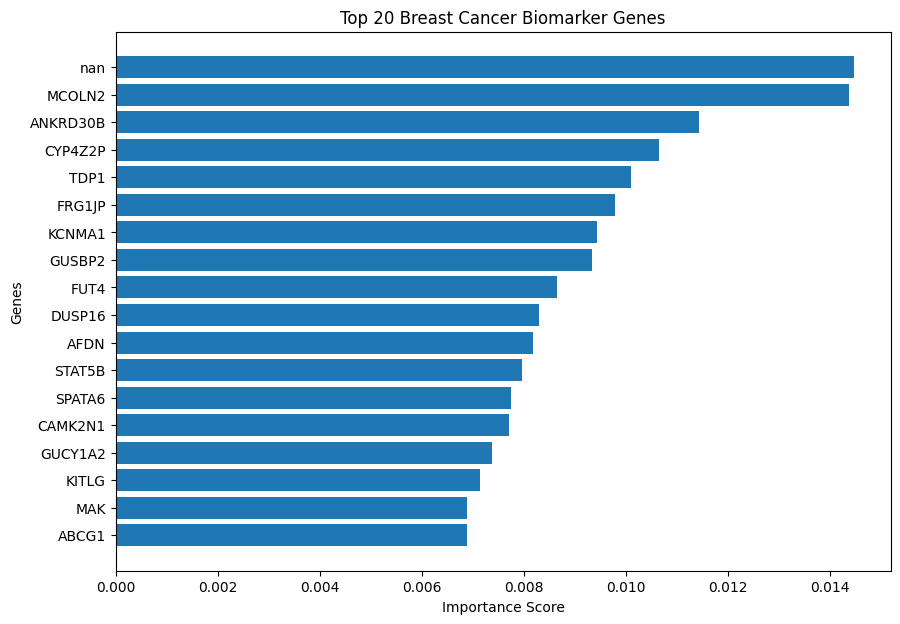

In [91]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,7))

plt.barh(
    top20['Gene'],
    top20['Importance']
)

plt.xlabel('Importance Score')
plt.ylabel('Genes')

plt.title('Top 20 Breast Cancer Biomarker Genes')

plt.gca().invert_yaxis()

plt.show()

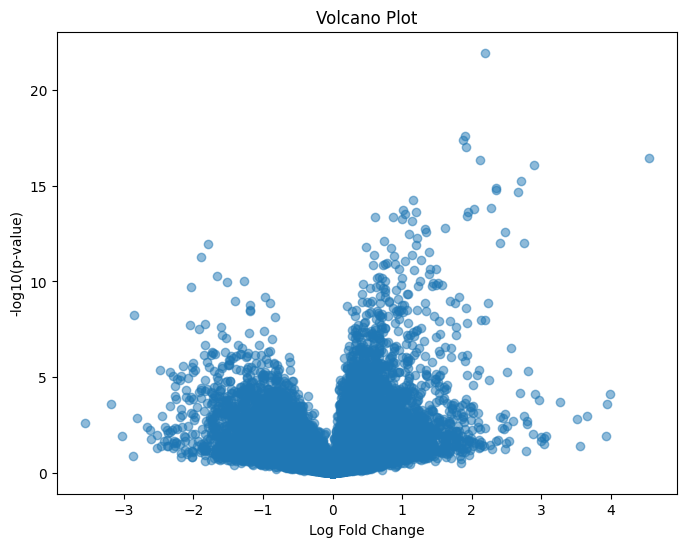

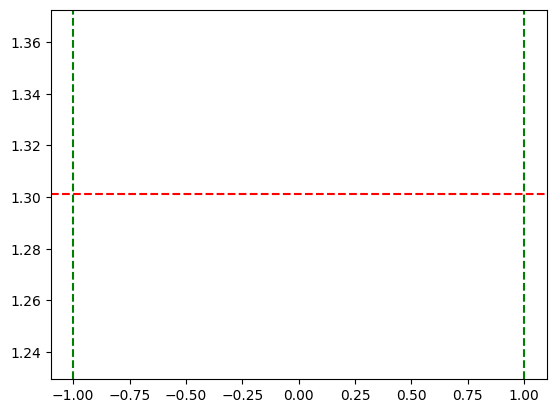

In [94]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Normal and cancer groups
normal = X.iloc[:11]
cancer = X.iloc[11:]

# Fold change
fc = cancer.mean() - normal.mean()

# Fast t-test
t_stat, p_values = ttest_ind(
    cancer,
    normal,
    axis=0,
    equal_var=False,
    nan_policy='omit'
)

# Create dataframe
volcano = pd.DataFrame({
    'Gene': X.columns,
    'logFC': fc.values,
    'pvalue': p_values
})

# Remove invalid values
volcano = volcano.dropna()

# Calculate -log10(p)
volcano['minuslog10p'] = -np.log10(volcano['pvalue'])

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    volcano['logFC'],
    volcano['minuslog10p'],
    alpha=0.5
)

plt.xlabel('Log Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot')

plt.show()
plt.axhline(y=-np.log10(0.05), color='red', linestyle='--')
plt.axvline(x=1, color='green', linestyle='--')
plt.axvline(x=-1, color='green', linestyle='--')

plt.show()

In [96]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', '_i2', 'pd', 'data', 'df', '_i3', 'np', 'plt', '_i4', 'load_breast_cancer', 'cancer', '_i5', '_i6', '_i7', 'train_test_split', 'X', 'y', 'X_train', 'X_test', 'y_train', 'y_test', '_i8', 'RandomForestClassifier', 'model', '_i9', 'y_pred', '_i10', 'accuracy_score', 'accuracy', '_i11', 'confusion_matrix', 'cm', '_i12', 'importance', 'feature_importance', '_i13', 'top_features', '_i14', 'roc_curve', 'auc', 'y_prob', 'fpr', 'tpr', 'thresholds', 'roc_auc', '_i15', '_i16', '_i17', '_i18', '_i19', '_i20', '_i21', '_i22', '_i23', 'df_transposed', '_i24', 'labels', '_i25', '_i26', '_i27', '_i28', '_i29', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', 'top_genes', '_i37', 'SVC', 'svm_model', 'svm_pred', 'svm_accuracy', '_i38', 'LogisticRegression', 'lr_model', 'lr_pred', 'lr

In [99]:
import pandas as pd

# Load dataset
data = pd.read_csv("GSE45827_series_matrix.txt.gz",
                   sep='\t',
                   comment='!',
                   compression='gzip')

# Remove unnecessary columns
expr_data = data.drop(columns=['ID_REF'])

# Keep only numeric columns
expr_data = expr_data.select_dtypes(include=['float64', 'int64'])

print(expr_data.shape)

(29873, 155)


In [100]:
from scipy.stats import ttest_ind
import numpy as np

# Split groups
group1 = expr_data.iloc[:, :77]
group2 = expr_data.iloc[:, 77:]

# Calculate log fold change
logFC = np.log2(group2.mean(axis=1) + 1) - np.log2(group1.mean(axis=1) + 1)

# Calculate p-values
pvals = []

for i in range(expr_data.shape[0]):
    stat, p = ttest_ind(group1.iloc[i], group2.iloc[i])
    pvals.append(p)

# Create DEG results
deg_results = pd.DataFrame({
    'logFC': logFC,
    'pvalue': pvals
})

print(deg_results.head())

      logFC        pvalue
0  0.007154  6.755128e-01
1 -0.165514  5.932347e-11
2 -0.124284  4.845977e-03
3  0.128892  6.815506e-05
4  0.038279  1.426394e-01


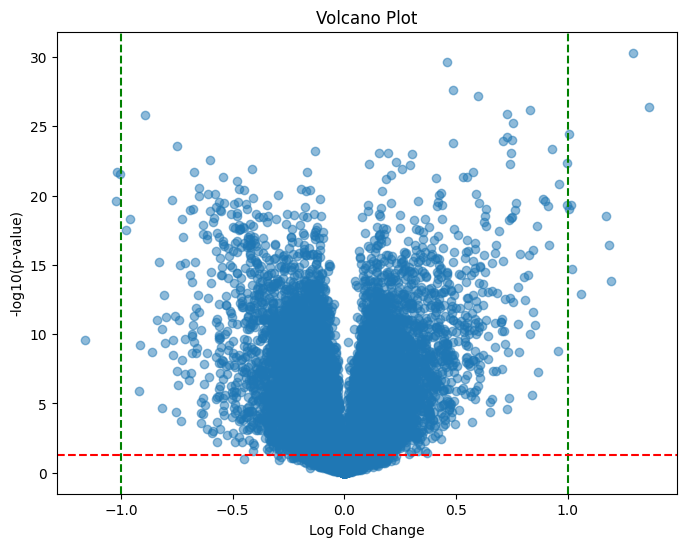

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# Volcano Plot
plt.figure(figsize=(8,6))

plt.scatter(deg_results['logFC'],
            -np.log10(deg_results['pvalue']),
            alpha=0.5)

# Threshold lines
plt.axvline(x=1, color='green', linestyle='--')
plt.axvline(x=-1, color='green', linestyle='--')
plt.axhline(y=-np.log10(0.05), color='red', linestyle='--')

# Labels
plt.title('Volcano Plot')
plt.xlabel('Log Fold Change')
plt.ylabel('-log10(p-value)')

plt.savefig("VolcanoPlot.png")

plt.show()

In [102]:
significant_genes = deg_results[
    (deg_results['pvalue'] < 0.05) &
    (abs(deg_results['logFC']) > 1)
]

print(significant_genes.head())
print("Total significant genes:", significant_genes.shape[0])

         logFC        pvalue
4758 -1.020540  2.608522e-20
6555 -1.004940  2.907689e-22
6556 -1.018702  1.911016e-22
6638  1.184137  3.944821e-17
6816  1.293164  4.848530e-31
Total significant genes: 14


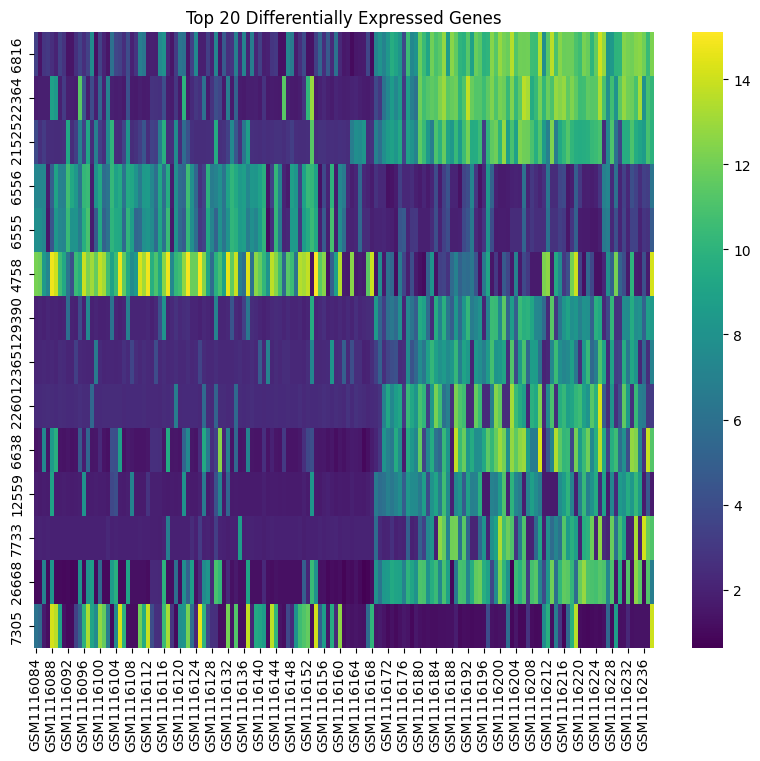

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 20 significant genes
top_genes = significant_genes.sort_values('pvalue').head(20)

# Expression values select
heatmap_data = expr_data.loc[top_genes.index]

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(heatmap_data,
            cmap='viridis')

plt.title("Top 20 Differentially Expressed Genes")
plt.savefig("Heatmap.png")
plt.show()

In [105]:
# Top 20 genes
top20 = significant_genes.sort_values('pvalue').head(20)

# Save as CSV
top20.to_csv("Top20_DEGs.csv")

print(top20.head())

          logFC        pvalue
6816   1.293164  4.848530e-31
22364  1.361566  3.798835e-27
21525  1.004935  3.367425e-25
6556  -1.018702  1.911016e-22
6555  -1.004940  2.907689e-22


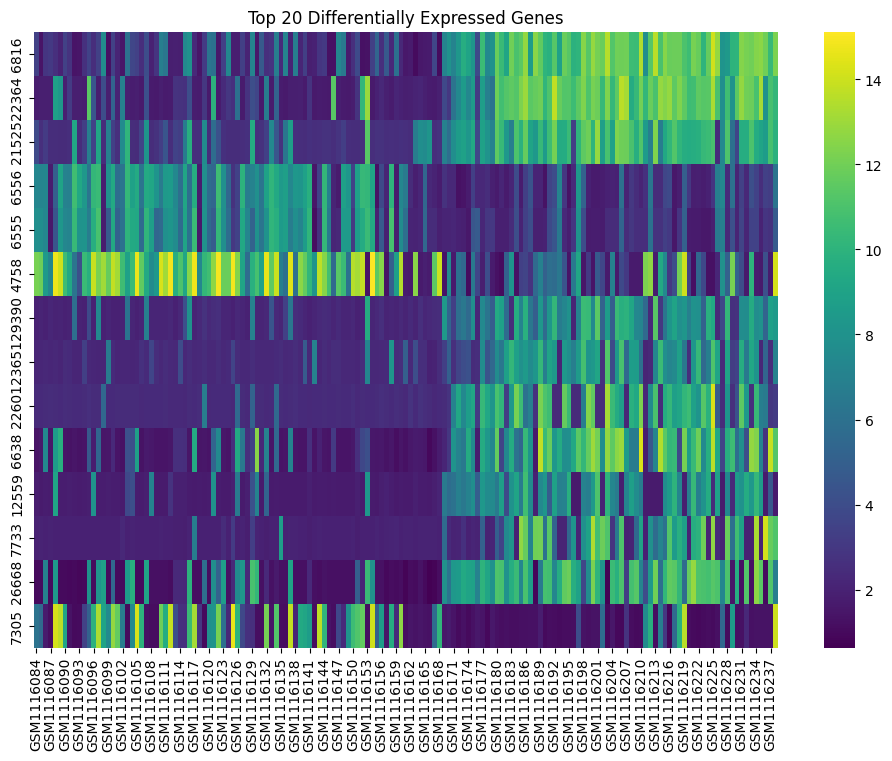

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 20 genes expression
heatmap_data = expr_data.loc[top20.index]

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    cmap='viridis'
)

plt.title("Top 20 Differentially Expressed Genes")
plt.show()

In [109]:
top20.head()

,logFC,pvalue
6816,1.293164,4.848530e-31
22364,1.361566,3.798835e-27
21525,1.004935,3.367425e-25
6556,-1.018702,1.911016e-22
6555,-1.004940,2.907689e-22


In [110]:
top20 = top20.merge(
    annot[['ID', 'Gene symbol']],
    left_index=True,
    right_index=True,
    how='left'
)

top20.head()

,logFC,pvalue,ID,Gene symbol
6816,1.293164,4.848530e-31,1562788_at,LINC01342
22364,1.361566,3.798835e-27,213061_s_at,NTAN1
21525,1.004935,3.367425e-25,212219_at,PSME4
6556,-1.018702,1.911016e-22,1562378_s_at,PROM2
6555,-1.004940,2.907689e-22,1562373_at,ITPR1


In [111]:
top20[['Gene symbol', 'logFC', 'pvalue']].head(20)

,Gene symbol,logFC,pvalue
6816,LINC01342,1.293164,4.848530e-31
22364,NTAN1,1.361566,3.798835e-27
21525,PSME4,1.004935,3.367425e-25
6556,PROM2,-1.018702,1.911016e-22
6555,ITPR1,-1.004940,2.907689e-22
4758,SYT7,-1.020540,2.608522e-20
29390,NPC1L1,1.012272,5.110567e-20
23651,KRAS,1.004286,9.804383e-20
22601,ATG2A,1.168759,2.755450e-19
6638,NaN,1.184137,3.944821e-17


In [112]:
top20.to_csv("Top20_DEGs.csv", index=False)

In [113]:
deg_results.to_csv("Full_DEG_Results.csv", index=False)

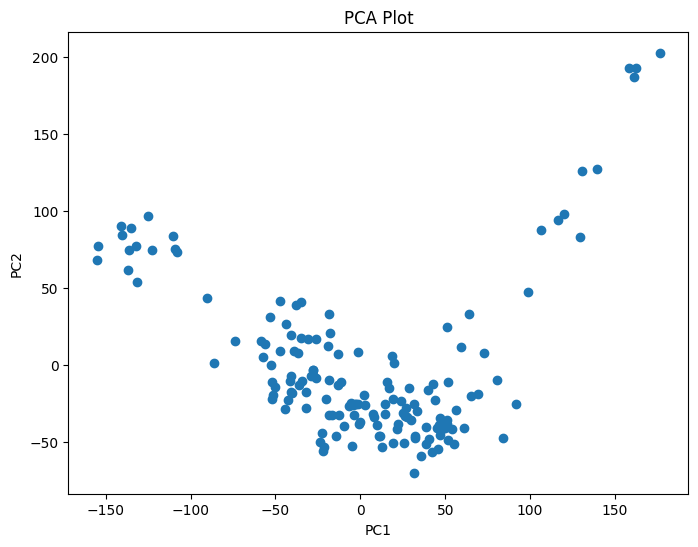

In [116]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# numeric only
expr_numeric = expr_data.iloc[:,1:].apply(pd.to_numeric, errors='coerce')

# transpose
X = expr_numeric.T

# scale
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# plot
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Plot")

plt.savefig("PCA_plot.png")

plt.show()

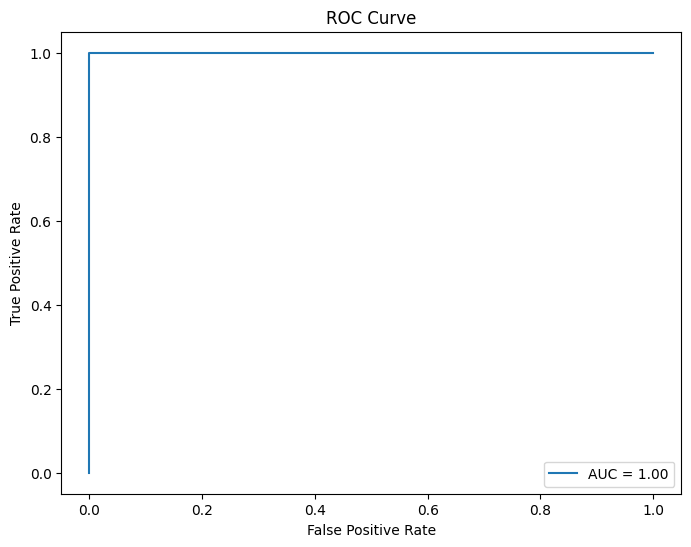

In [118]:
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Example labels
y = [0]*77 + [1]*77

X = expr_numeric.T.fillna(0)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predict probability
y_score = model.predict_proba(X_test)[:,1]

# ROC
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.savefig("ROC_Curve.png")

plt.show()

In [3]:
import pandas as pd
import numpy as np

In [8]:
import os
print(os.listdir())

['.config', 'GPL570.annot.gz', 'GSE45827_series_matrix.txt.gz', 'sample_data']


In [9]:
import pandas as pd

data = pd.read_csv(
    "/content/GSE45827_series_matrix.txt.gz",
    sep='\t',
    comment='!',
    low_memory=False
)

print(data.head())

      ID_REF  GSM1116084  GSM1116085  GSM1116086  GSM1116087  GSM1116088  \
0  1007_s_at     9.47065     9.67440    10.20800    10.11420    11.16360   
1    1053_at     8.36311     8.72194     7.78601     9.44537     7.71242   
2     117_at     5.95426     7.02523     6.39671     4.56023     5.29008   
3    1294_at     6.02119     7.24581     6.85310     5.42786     7.51120   
4    1316_at     3.22997     3.29352     3.26204     3.34766     3.59086   

   GSM1116089  GSM1116090  GSM1116091  GSM1116092  ...  GSM1116229  \
0    10.00690     9.53932     9.00187     6.54074  ...     9.96811   
1     7.84274     7.56238     8.01540     9.37874  ...     7.25745   
2     6.21590     6.42180     6.23554     5.43541  ...     8.35832   
3     5.79719     7.36700     7.17268     7.72472  ...     7.18591   
4     3.40108     3.27663     3.14212     3.28420  ...     3.50312   

   GSM1116230  GSM1116231  GSM1116232  GSM1116233  GSM1116234  GSM1116235  \
0    10.10680    10.03290     9.84599    10.7

In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Remove first column if it contains gene IDs
X = data.iloc[:, 1:].T

# Convert to numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Fill missing values
X = X.fillna(0)

# Create labels
# First 77 = Cancer
# Remaining = Normal

y = [1]*77 + [0]*(len(X)-77)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train model
model = RandomForestClassifier()

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Report
print(classification_report(y_test, y_pred))

Accuracy: 0.967741935483871
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.94      1.00      0.97        15

    accuracy                           0.97        31
   macro avg       0.97      0.97      0.97        31
weighted avg       0.97      0.97      0.97        31



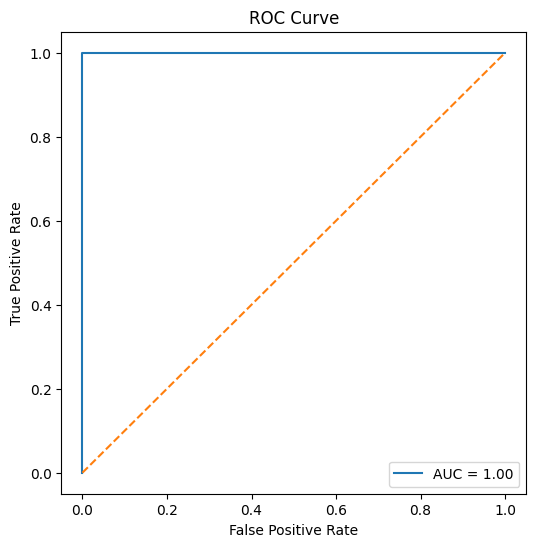

In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability prediction
y_prob = model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.savefig("ROC_Curve.png")
plt.show()

In [12]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

top_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(top_features.head(10))

       Feature  Importance
13574    13574    0.014997
15007    15007    0.013949
20760    20760    0.012451
11240    11240    0.012293
3299      3299    0.012216
13717    13717    0.011534
29077    29077    0.010398
6816      6816    0.009636
6677      6677    0.007886
5734      5734    0.007592


In [13]:
import joblib

joblib.dump(model, "breast_cancer_model.pkl")

print("Model saved successfully")

Model saved successfully


In [14]:
top_features.head(20).to_csv("Top_Genes.csv", index=False)

In [15]:
import pandas as pd

importance = pd.DataFrame({
    'Gene': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(20))

        Gene  Importance
13574  13574    0.014997
15007  15007    0.013949
20760  20760    0.012451
11240  11240    0.012293
3299    3299    0.012216
13717  13717    0.011534
29077  29077    0.010398
6816    6816    0.009636
6677    6677    0.007886
5734    5734    0.007592
8425    8425    0.007322
9732    9732    0.007208
8436    8436    0.007148
1361    1361    0.007064
13448  13448    0.007032
8069    8069    0.006996
16540  16540    0.006985
15052  15052    0.006887
5374    5374    0.006806
5428    5428    0.006784


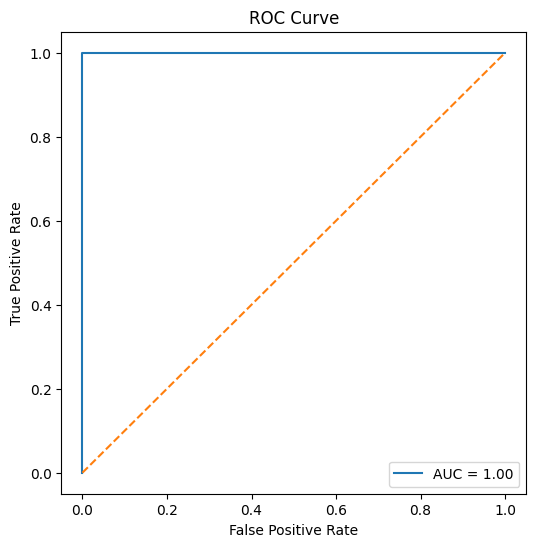

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.savefig("ROC_Curve.png")
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

# Models
models = {
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

# Store accuracies
results = []

# Train and test each model
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append([name, acc])

# Create result table
results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy']
)

print(results_df)

                 Model  Accuracy
0        Random Forest  1.000000
1                  SVM  0.903226
2  Logistic Regression  1.000000


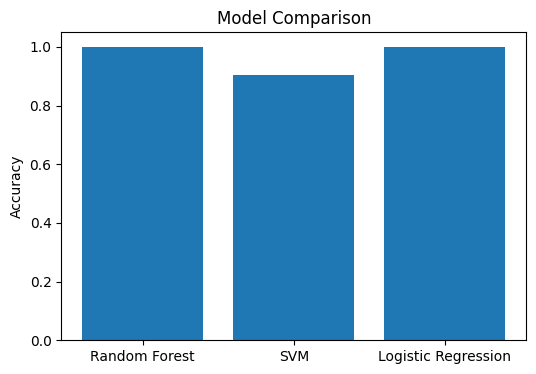

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(results_df['Model'],
        results_df['Accuracy'])

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.savefig("Model_Comparison.png")

plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get importance from Logistic Regression
importance = np.abs(model.coef_[0])

# Create dataframe
feature_df = pd.DataFrame({
    'Gene': X.columns,
    'Importance': importance
})

# Sort values
feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

# Top 10 genes
top10 = feature_df.head(10)

print(top10)

        Gene  Importance
22364  22364    0.025007
6816    6816    0.021949
5734    5734    0.015802
21525  21525    0.014752
7733    7733    0.014611
10094  10094    0.014591
6225    6225    0.013862
6555    6555    0.013821
5611    5611    0.013817
13574  13574    0.013651


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Logistic Regression coefficients
importance = np.abs(model.coef_[0])

# Feature names
genes = X.columns

# Dataframe
feature_df = pd.DataFrame({
    'Gene': genes,
    'Importance': importance
})

# Remove zero values
feature_df = feature_df[feature_df['Importance'] > 0]

# Sort descending
feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

# Top 10
top10 = feature_df.head(10)

print(top10)

        Gene  Importance
22364  22364    0.025007
6816    6816    0.021949
5734    5734    0.015802
21525  21525    0.014752
7733    7733    0.014611
10094  10094    0.014591
6225    6225    0.013862
6555    6555    0.013821
5611    5611    0.013817
13574  13574    0.013651


In [24]:
print(top10.shape)

print(top10.head())

(10, 2)
        Gene  Importance
22364  22364    0.025007
6816    6816    0.021949
5734    5734    0.015802
21525  21525    0.014752
7733    7733    0.014611


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Logistic Regression coefficient values
importance = np.abs(model.coef_[0])

# Create dataframe
feature_df = pd.DataFrame({
    'Gene': X.columns,
    'Importance': importance
})

# Sort
feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

# Take top 10 directly
top10 = feature_df.head(10)

print(top10)

        Gene  Importance
22364  22364    0.025007
6816    6816    0.021949
5734    5734    0.015802
21525  21525    0.014752
7733    7733    0.014611
10094  10094    0.014591
6225    6225    0.013862
6555    6555    0.013821
5611    5611    0.013817
13574  13574    0.013651


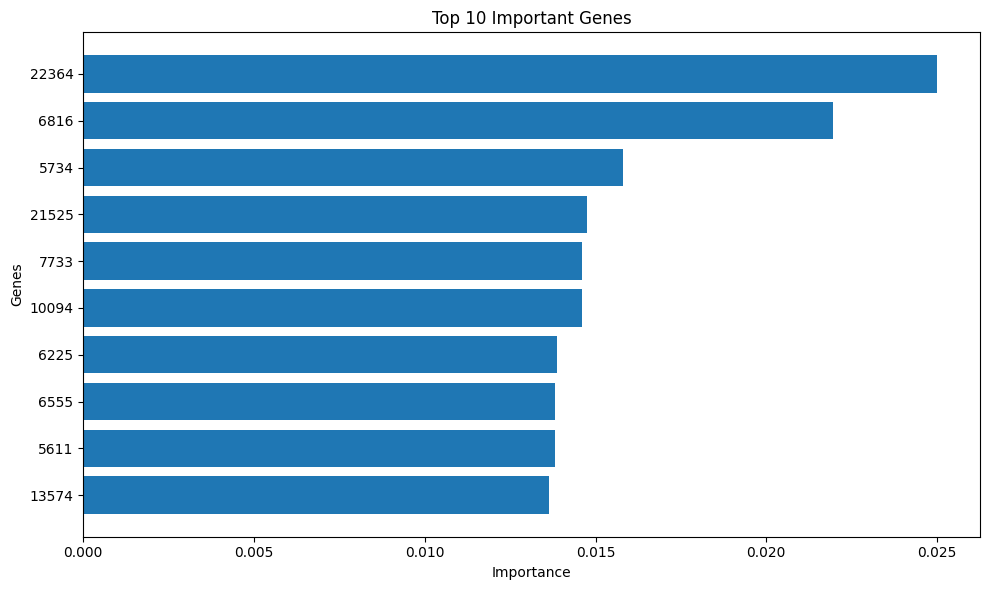

In [27]:
plt.figure(figsize=(10,6))

plt.barh(
    top10['Gene'].astype(str),
    top10['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Genes")
plt.title("Top 10 Important Genes")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("Top10_Important_Genes.png", dpi=300, bbox_inches='tight')

plt.show()

In [32]:
import pandas as pd

# Feature importance dataframe
importance_df = pd.DataFrame({
    'Gene': X.columns,
    'Importance': importance
})

# Sort values
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Show top 10
top_genes = importance_df.head(10)

print(top_genes)

        Gene  Importance
22364  22364    0.025007
6816    6816    0.021949
5734    5734    0.015802
21525  21525    0.014752
7733    7733    0.014611
10094  10094    0.014591
6225    6225    0.013862
6555    6555    0.013821
5611    5611    0.013817
13574  13574    0.013651


In [35]:
print(data.columns)

Index(['ID_REF', 'GSM1116084', 'GSM1116085', 'GSM1116086', 'GSM1116087',
       'GSM1116088', 'GSM1116089', 'GSM1116090', 'GSM1116091', 'GSM1116092',
       ...
       'GSM1116229', 'GSM1116230', 'GSM1116231', 'GSM1116232', 'GSM1116233',
       'GSM1116234', 'GSM1116235', 'GSM1116236', 'GSM1116237', 'GSM1116238'],
      dtype='object', length=156)


In [36]:
top_genes = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

print(top_genes)

     Gene  Importance
0   22364    0.025007
1    6816    0.021949
2    5734    0.015802
3   21525    0.014752
4    7733    0.014611
5   10094    0.014591
6    6225    0.013862
7    6555    0.013821
8    5611    0.013817
9   13574    0.013651
10    559    0.013418
11   6557    0.012879
12   4758    0.012831
13   6248    0.012734
14   7030    0.012725
15   6556    0.012692
16  16487    0.012321
17   5342    0.012223
18  20874    0.012063
19   6407    0.011747


In [38]:
print(data.columns[:20])

Index(['ID_REF', 'GSM1116084', 'GSM1116085', 'GSM1116086', 'GSM1116087',
       'GSM1116088', 'GSM1116089', 'GSM1116090', 'GSM1116091', 'GSM1116092',
       'GSM1116093', 'GSM1116094', 'GSM1116095', 'GSM1116096', 'GSM1116097',
       'GSM1116098', 'GSM1116099', 'GSM1116100', 'GSM1116101', 'GSM1116102'],
      dtype='object')


In [41]:
# Get importance from Logistic Regression
importance = abs(model.coef_[0])

# Gene names
gene_names = data['ID_REF'][:len(importance)]

# Create dataframe
importance_df = pd.DataFrame({
    'Gene': gene_names.values,
    'Importance': importance
})

# Top 20 genes
top_genes = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

print(top_genes)

               Gene  Importance
22364     228241_at    0.025007
6816      205225_at    0.021949
5734      203963_at    0.015802
21525     227198_at    0.014752
7733    206754_s_at    0.014611
10094   210735_s_at    0.014591
6225    204508_s_at    0.013862
6555    204913_s_at    0.013821
5611      203824_at    0.013817
13574   215867_x_at    0.013651
559    1554712_a_at    0.013418
6557    204915_s_at    0.012879
4758    202917_s_at    0.012831
6248      204540_at    0.012734
7030      205509_at    0.012725
6556    204914_s_at    0.012692
16487     220414_at    0.012321
5342      203535_at    0.012223
20874     226473_at    0.012063
6407      204733_at    0.011747


In [42]:
top_genes.to_csv("top_genes.csv", index=False)

In [43]:
gene_list = [
"228241_at",
"205225_at",
"203963_at",
"227198_at",
"206754_s_at",
"210735_s_at",
"204508_s_at",
"204913_at",
"203824_at",
"215867_x_at",
"1554712_a_at",
"204915_s_at",
"202917_s_at",
"204540_at",
"205509_at",
"204914_s_at",
"220414_at",
"203535_at",
"226473_at",
"204733_at"
]

for gene in gene_list:
    print(gene.split('_')[0])

228241
205225
203963
227198
206754
210735
204508
204913
203824
215867
1554712
204915
202917
204540
205509
204914
220414
203535
226473
204733


In [49]:
import gzip

with gzip.open("GPL570.annot.gz", "rt") as f:
    for i in range(40):
        print(f.readline())

^Annotation

!Annotation_date = Aug 09 2016

!Annotation_platform = GPL570

!Annotation_platform_title = [HG-U133_Plus_2] Affymetrix Human Genome U133 Plus 2.0 Array

!Annotation_platform_organism = Homo sapiens

#ID = ID from Platform data table

#Gene title = Entrez Gene name

#Gene symbol = Entrez Gene symbol

#Gene ID = Entrez Gene identifier

#UniGene title = Entrez UniGene name

#UniGene symbol = Entrez UniGene symbol

#UniGene ID = Entrez UniGene identifier

#Nucleotide Title = Entrez Nucleotide title

#GI = GenBank identifier

#GenBank Accession = GenBank accession

#Platform_CLONEID = CLONE_ID from Platform data table

#Platform_ORF = ORF from Platform data table

#Platform_SPOTID = SPOT_ID from Platform data table

#Chromosome location = Entrez gene chromosome and location

#Chromosome annotation = Entrez gene chromosome annotation

#GO:Function = Gene Ontology Function term

#GO:Process = Gene Ontology Process term

#GO:Component = Gene Ontology Component term

#GO:Function 

In [50]:
import pandas as pd

annot = pd.read_csv(
    "GPL570.annot.gz",
    sep="\t",
    compression="gzip",
    skiprows=27
)

annot.head()

/tmp/ipykernel_1659/3883906531.py:3: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  annot = pd.read_csv(


,ID,Gene title,Gene symbol,Gene ID,UniGene title,UniGene symbol,UniGene ID,Nucleotide Title,GI,GenBank Accession,...,Platform_ORF,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID
0,1007_s_at,microRNA 4640///discoidin domain receptor tyro...,MIR4640///DDR1,100616237///780,NaN,NaN,NaN,"Human receptor tyrosine kinase DDR gene, compl...",1753221.0,U48705,...,NaN,NaN,6p21.3,"Chromosome 6, NC_000006.12 (30890883..30890972...",ATP binding///collagen binding///collagen bind...,branching involved in mammary gland duct morph...,basolateral plasma membrane///extracellular ex...,GO:0005524///GO:0005518///GO:0005518///GO:0046...,GO:0060444///GO:0007155///GO:0038063///GO:0038...,GO:0016323///GO:0070062///GO:0005615///GO:0005...
1,1053_at,replication factor C subunit 2,RFC2,5982,NaN,NaN,NaN,"Human replication factor C, 40-kDa subunit (A1...",1590810.0,M87338,...,NaN,NaN,7q11.23,"Chromosome 7, NC_000007.14 (74231502..74254458...",ATP binding///contributes_to DNA clamp loader ...,"DNA damage response, detection of DNA damage//...",Ctf18 RFC-like complex///DNA replication facto...,GO:0005524///contributes_to GO:0003689///GO:00...,GO:0042769///GO:0006260///GO:0070987///GO:0042...,GO:0031390///GO:0005663///GO:0005654
2,117_at,heat shock protein family A (Hsp70) member 6,HSPA6,3310,NaN,NaN,NaN,Human heat-shock protein HSP70B' gene,35221.0,X51757,...,NaN,NaN,1q23,"Chromosome 1, NC_000001.11 (161524540..161526897)","ATP binding///ATPase activity, coupled///enzym...",NOT cellular heat acclimation///cellular respo...,colocalizes_with COP9 signalosome///blood micr...,GO:0005524///GO:0042623///GO:0019899///GO:0031...,NOT GO:0070370///GO:0034605///GO:0034605///GO:...,colocalizes_with GO:0008180///GO:0072562///GO:...
3,121_at,paired box 8,PAX8,7849,NaN,NaN,NaN,H.sapiens Pax8 mRNA,38425.0,X69699,...,NaN,NaN,2q13,"Chromosome 2, NC_000002.12 (113215997..1132789...",DNA binding///DNA binding///RNA polymerase II ...,anatomical structure morphogenesis///branching...,nucleoplasm///nucleoplasm///nucleus,GO:0003677///GO:0003677///GO:0000978///GO:0000...,GO:0009653///GO:0001658///GO:0071371///GO:0007...,GO:0005654///GO:0005654///GO:0005634
4,1255_g_at,guanylate cyclase activator 1A,GUCA1A,2978,NaN,NaN,NaN,Homo sapiens guanylate cyclase activating prot...,623404.0,L36861,...,NaN,NaN,6p21.1,"Chromosome 6, NC_000006.12 (42155377..42180083)",calcium ion binding///calcium sensitive guanyl...,cellular response to calcium ion///phototransd...,photoreceptor disc membrane///photoreceptor in...,GO:0005509///GO:0008048///GO:0030249,GO:0071277///GO:0007602///GO:0031284///GO:0022...,GO:0097381///GO:0001917///GO:0005886


In [51]:
gene_info = annot[['ID', 'Gene symbol']]

gene_info.head()

,ID,Gene symbol
0,1007_s_at,MIR4640///DDR1
1,1053_at,RFC2
2,117_at,HSPA6
3,121_at,PAX8
4,1255_g_at,GUCA1A


In [52]:
importance_df = importance_df.reset_index(drop=True)
gene_info = gene_info.reset_index(drop=True)

importance_df['Gene symbol'] = gene_info['Gene symbol']

importance_df.head()

,Gene,Importance,Gene symbol
0,1007_s_at,0.000660,MIR4640///DDR1
1,1053_at,0.000799,RFC2
2,117_at,0.000137,HSPA6
3,1294_at,0.000397,PAX8
4,1316_at,0.000213,GUCA1A


In [53]:
top_genes = importance_df.sort_values(
    by='Importance',
    ascending=False
)

top_genes.head(20)

,Gene,Importance,Gene symbol
22364,228241_at,0.025007,NTAN1
6816,205225_at,0.021949,LINC01342
5734,203963_at,0.015802,LOC101928850
21525,227198_at,0.014752,PSME4
7733,206754_s_at,0.014611,NaN
10094,210735_s_at,0.014591,NUCB1
6225,204508_s_at,0.013862,NaN
6555,204913_s_at,0.013821,ITPR1
5611,203824_at,0.013817,TLX1NB
13574,215867_x_at,0.013651,RFC3


/tmp/ipykernel_1659/4217405678.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top20['Gene symbol'] = top20['Gene symbol'].astype(str)


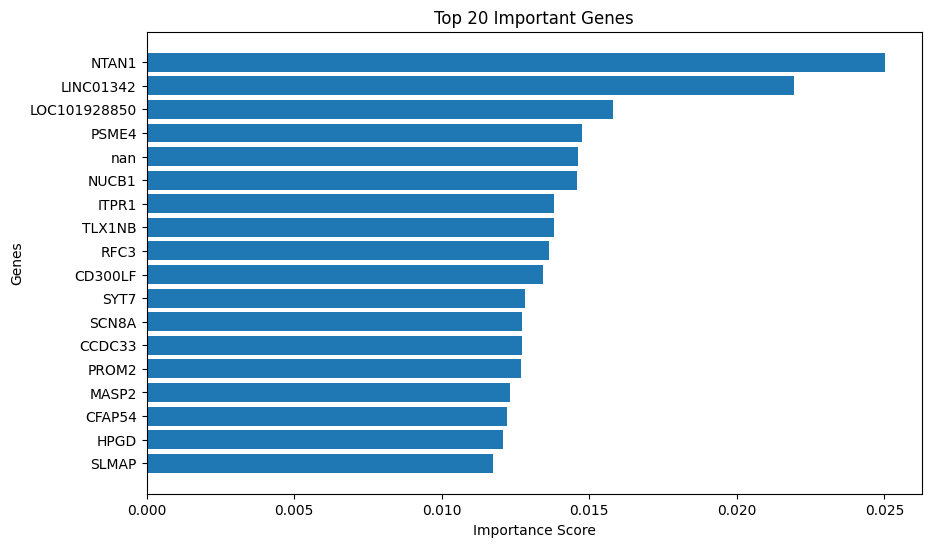

In [56]:
import matplotlib.pyplot as plt

top20 = top_genes.head(20)

# Convert gene names to string
top20['Gene symbol'] = top20['Gene symbol'].astype(str)

plt.figure(figsize=(10,6))
plt.barh(top20['Gene symbol'], top20['Importance'])

plt.xlabel("Importance Score")
plt.ylabel("Genes")
plt.title("Top 20 Important Genes")

plt.gca().invert_yaxis()

plt.savefig("top20_genes.png", dpi=300, bbox_inches='tight')

plt.show()

In [57]:
print(top20[['Gene symbol', 'Importance']])

        Gene symbol  Importance
22364         NTAN1    0.025007
6816      LINC01342    0.021949
5734   LOC101928850    0.015802
21525         PSME4    0.014752
7733            nan    0.014611
10094         NUCB1    0.014591
6225            nan    0.013862
6555          ITPR1    0.013821
5611         TLX1NB    0.013817
13574          RFC3    0.013651
559         CD300LF    0.013418
6557            nan    0.012879
4758           SYT7    0.012831
6248          SCN8A    0.012734
7030         CCDC33    0.012725
6556          PROM2    0.012692
16487         MASP2    0.012321
5342         CFAP54    0.012223
20874          HPGD    0.012063
6407          SLMAP    0.011747


In [58]:
top20[['Gene symbol']].to_csv("top_genes.txt", index=False, header=False)

In [59]:
!pip install GEOparse

In [62]:
import pandas as pd

# Load your expression file
df = pd.read_csv("/content/GSE45827_series_matrix.txt.gz", sep="\t", comment="!")

print(df.head())

      ID_REF  GSM1116084  GSM1116085  GSM1116086  GSM1116087  GSM1116088  \
0  1007_s_at     9.47065     9.67440    10.20800    10.11420    11.16360   
1    1053_at     8.36311     8.72194     7.78601     9.44537     7.71242   
2     117_at     5.95426     7.02523     6.39671     4.56023     5.29008   
3    1294_at     6.02119     7.24581     6.85310     5.42786     7.51120   
4    1316_at     3.22997     3.29352     3.26204     3.34766     3.59086   

   GSM1116089  GSM1116090  GSM1116091  GSM1116092  ...  GSM1116229  \
0    10.00690     9.53932     9.00187     6.54074  ...     9.96811   
1     7.84274     7.56238     8.01540     9.37874  ...     7.25745   
2     6.21590     6.42180     6.23554     5.43541  ...     8.35832   
3     5.79719     7.36700     7.17268     7.72472  ...     7.18591   
4     3.40108     3.27663     3.14212     3.28420  ...     3.50312   

   GSM1116230  GSM1116231  GSM1116232  GSM1116233  GSM1116234  GSM1116235  \
0    10.10680    10.03290     9.84599    10.7

In [63]:
df = df.rename(columns={'ID_REF':'Gene'})

In [64]:
cancer = df.iloc[:,1:11]
normal = df.iloc[:,11:21]

In [65]:
from scipy.stats import ttest_ind
import numpy as np

pvals = []
logFC = []

for i in range(len(df)):
    c = cancer.iloc[i].astype(float)
    n = normal.iloc[i].astype(float)

    stat, p = ttest_ind(c, n)

    pvals.append(p)
    logFC.append(np.mean(c) - np.mean(n))

results = pd.DataFrame({
    'Gene': df['Gene'],
    'logFC': logFC,
    'pvalue': pvals
})

print(results.head())

        Gene     logFC    pvalue
0  1007_s_at -0.133089  0.774927
1    1053_at  0.380523  0.216628
2     117_at -0.222184  0.658111
3    1294_at  0.097555  0.832077
4    1316_at -0.306182  0.208054


In [66]:
sig = results[(results['pvalue'] < 0.05) & (abs(results['logFC']) > 1)]

print(sig.head())

             Gene     logFC    pvalue
183  1553102_a_at -1.013945  0.027804
189  1553112_s_at -1.008091  0.014641
196  1553132_a_at -1.948364  0.015139
226  1553292_s_at -1.462044  0.019990
271  1553663_a_at  1.814529  0.038770


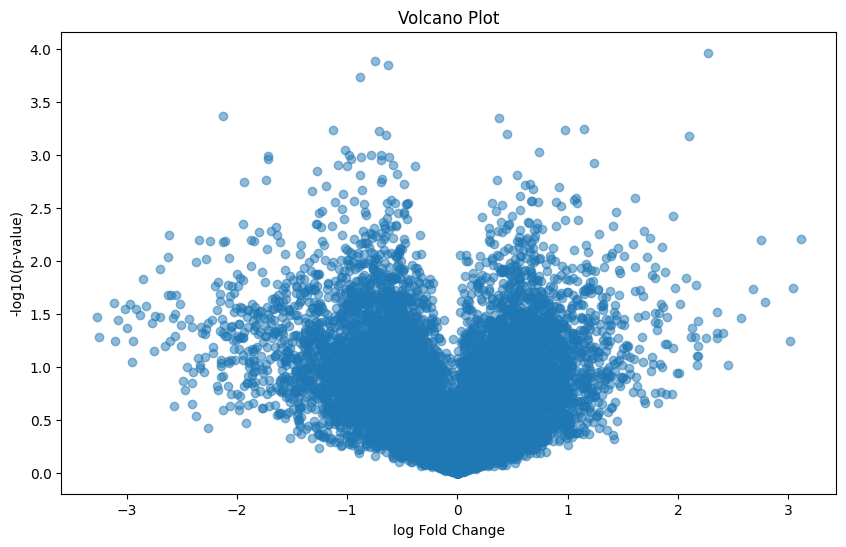

In [82]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

plt.scatter(results['logFC'],
            -np.log10(results['pvalue']),
            alpha=0.5)

plt.xlabel("log Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot")

plt.savefig("volcano.png")

plt.show()

In [68]:
sig.to_csv("Significant_Genes.csv", index=False)

In [69]:
!pip install seaborn

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

In [71]:
top_genes = sig.head(20)['Gene']

heatmap_data = df[df['Gene'].isin(top_genes)]

In [72]:
heatmap_values = heatmap_data.iloc[:,1:]

In [74]:
heatmap_values = heatmap_values.apply(pd.to_numeric, errors='coerce')

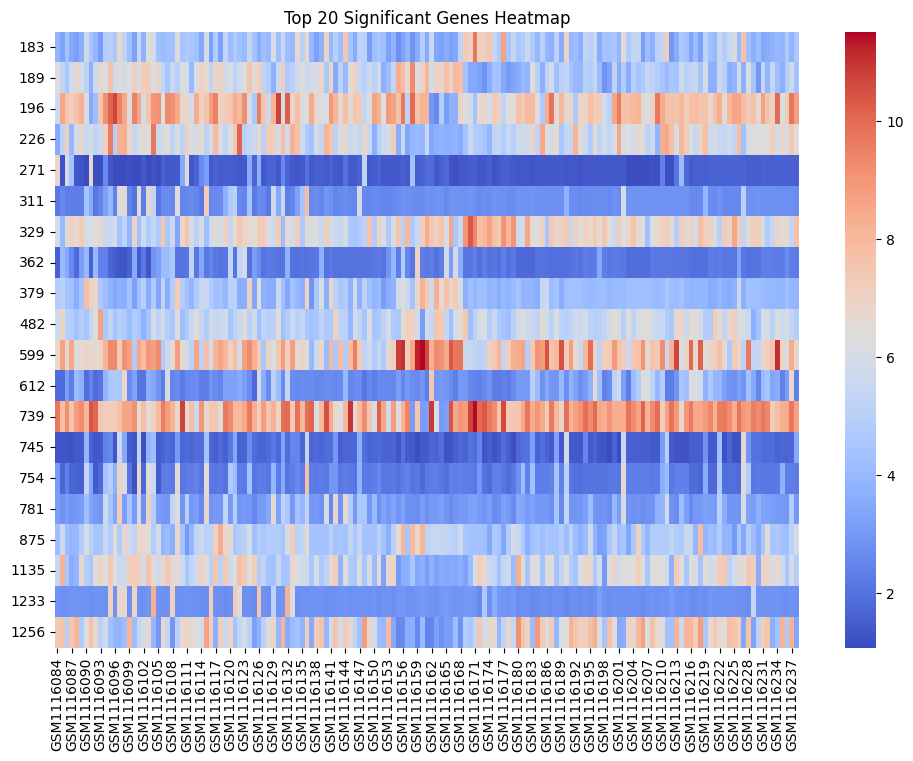

In [76]:
plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_values,
    cmap='coolwarm'
)

plt.title("Top 20 Significant Genes Heatmap")

plt.savefig("heatmap.png")

plt.show()

In [77]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [78]:
y_prob = model.predict_proba(X_test)[:,1]

In [79]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 1.0


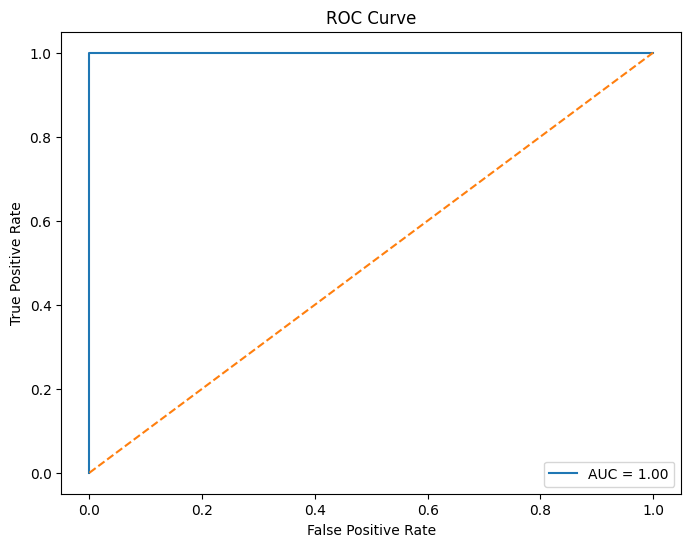

In [81]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig("ROC_curve.png", dpi=300, bbox_inches='tight')

plt.show()